<a href="https://colab.research.google.com/github/PunamBhatia/LogicMojo-AI-ML-April26-Punam/blob/main/MLP_Assignments/MLP_Tabular_Rice_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#!pip install opendatasets
#import opendatasets as od
#od.download("https://www.kaggle.com/datasets/mssmartypants/rice-type-classification")

In [2]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

device='cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [3]:
data_df=pd.read_csv('/content/drive/MyDrive/LogicMojo/riceClassification.csv')
data_df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [4]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18185 entries, 0 to 18184
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               18185 non-null  int64  
 1   Area             18185 non-null  int64  
 2   MajorAxisLength  18185 non-null  float64
 3   MinorAxisLength  18185 non-null  float64
 4   Eccentricity     18185 non-null  float64
 5   ConvexArea       18185 non-null  int64  
 6   EquivDiameter    18185 non-null  float64
 7   Extent           18185 non-null  float64
 8   Perimeter        18185 non-null  float64
 9   Roundness        18185 non-null  float64
 10  AspectRation     18185 non-null  float64
 11  Class            18185 non-null  int64  
dtypes: float64(8), int64(4)
memory usage: 1.7 MB


In [5]:
data_df.dropna(inplace=True)
data_df.drop(['id'],axis=1, inplace=True)
print(data_df.shape)


(18185, 11)


In [6]:
#lets chk for target imbalance
print(data_df['Class'].unique())
data_df['Class'].value_counts()

[1 0]


,count
Class,
1,9985
0,8200


In [7]:
#lets do the standardization
original_df=data_df.copy()
for column in data_df.columns:
  data_df[column]=data_df[column]/data_df[column].abs().max()

data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [8]:
#lets separate X (features)and Y(target)
X=np.array(data_df.iloc[:,:-1])
Y=np.array(data_df.iloc[:,-1])

In [9]:
X_train, X_test, Y_train, Y_test=train_test_split(X,Y, test_size=0.3, random_state=42)
print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

X_test, X_val, Y_test, Y_val= train_test_split(X_test, Y_test, test_size=0.5, random_state=42)
print(X_test.shape, X_val.shape, Y_test.shape, Y_val.shape)

(12729, 10) (5456, 10) (12729,) (5456,)
(2728, 10) (2728, 10) (2728,) (2728,)


In [10]:
class dataset(Dataset):
  def __init__(self, X, Y):
    self.X=torch.tensor(X, dtype=torch.float32).to(device)
    self.Y=torch.tensor(Y, dtype=torch.float32).to(device)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.Y[idx]

training_data=dataset(X_train, Y_train)
testing_data=dataset(X_test, Y_test)
validation_data=dataset(X_val, Y_val)


training_dataloader=DataLoader(training_data, batch_size=32, shuffle=True)
testing_dataloader=DataLoader(testing_data, batch_size=32, shuffle=True)
validation_dataloader=DataLoader(validation_data, batch_size=32, shuffle=True)


In [11]:
#lets define module
HIDDEN_NEURONS=10
class MyModel(nn.Module):
  def __init__(self):
    super(MyModel, self).__init__()
    self.inputLayer=nn.Linear(X.shape[1],HIDDEN_NEURONS)
    self.linear=nn.Linear(HIDDEN_NEURONS,1)
    self.sigmoid=nn.Sigmoid()

  def forward(self, x):
    x=self.inputLayer(x)
    x=self.linear(x)
    x=self.sigmoid(x)
    return x

In [12]:
model= MyModel().to(device)
summary(model, (X.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             110
            Linear-2                    [-1, 1]              11
           Sigmoid-3                    [-1, 1]               0
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [13]:
criterion= nn.BCELoss()
optimizer= Adam(model.parameters(), lr=1e-3)

total_loss_train_plot=[]
total_loss_val_plot=[]
total_acc_train_plot=[]
total_acc_val_plot=[]

epochs=10

for epoch in range(epochs):
  total_loss_train=0
  total_loss_val=0
  total_acc_train=0
  total_acc_val=0
  for data in training_dataloader:
    inputs, labels=data
    optimizer.zero_grad()
    predictions=model(inputs).squeeze(1)

    batch_loss=criterion(predictions, labels)
    total_loss_train+=batch_loss.item()

    #print(f"predictions={predictions}, labels={labels}")
    acc = ((predictions).round() == labels).sum().item()
    total_acc_train += acc

    batch_loss.backward()
    optimizer.step()


  with torch.no_grad():
    for data in validation_dataloader:
      inputs, labels=data
      outputs=model(inputs).squeeze(1)
      batch_loss=criterion(outputs, labels)
      total_loss_val+=batch_loss.item()

      acc = (outputs.round() == labels).sum().item()
      total_acc_val += acc


  total_loss_train_plot.append(round(total_loss_train/1000,4))
  total_loss_val_plot.append(round(total_loss_val/1000,4))
  total_acc_train_plot.append(round((total_acc_train * 100)/training_data.__len__(),4))
  total_acc_val_plot.append(round((total_acc_val* 100)/validation_data.__len__(),4))

  print(f'''Epoch no.{ epoch+1}
  Train Loss: {round(total_loss_train/1000,4)}
  Train Accuracy: {round((total_acc_train * 100)/training_data.__len__(),4)},
  Validation Loss: {round(total_loss_val/1000,4)}
  Validation Accuracy: {round((total_acc_val*100)/validation_data.__len__(),4)}''')

  print("="*30)


Epoch no.1
  Train Loss: 0.242
  Train Accuracy: 78.7022,
  Validation Loss: 0.0402
  Validation Accuracy: 98.2405
Epoch no.2
  Train Loss: 0.1267
  Train Accuracy: 97.5803,
  Validation Loss: 0.017
  Validation Accuracy: 98.3138
Epoch no.3
  Train Loss: 0.0596
  Train Accuracy: 98.1695,
  Validation Loss: 0.0094
  Validation Accuracy: 98.5337
Epoch no.4
  Train Loss: 0.0377
  Train Accuracy: 98.3581,
  Validation Loss: 0.0067
  Validation Accuracy: 98.6437
Epoch no.5
  Train Loss: 0.029
  Train Accuracy: 98.4759,
  Validation Loss: 0.0056
  Validation Accuracy: 98.5337
Epoch no.6
  Train Loss: 0.0246
  Train Accuracy: 98.4838,
  Validation Loss: 0.0049
  Validation Accuracy: 98.607
Epoch no.7
  Train Loss: 0.0221
  Train Accuracy: 98.5702,
  Validation Loss: 0.0046
  Validation Accuracy: 98.5337
Epoch no.8
  Train Loss: 0.0204
  Train Accuracy: 98.5466,
  Validation Loss: 0.0043
  Validation Accuracy: 98.5337
Epoch no.9
  Train Loss: 0.0195
  Train Accuracy: 98.5309,
  Validation Loss

In [14]:
#lets start testing
with torch.no_grad():
  total_loss_test=0
  total_acc_test=0
  for data in testing_dataloader:
    inputs, labels= data

    predictions= model(inputs).squeeze(1)
    batch_loss=criterion(predictions, labels)
    total_loss_test+=batch_loss.item()

    acc = (predictions.round() == labels).sum().item()
    total_acc_test += acc

  print(f"Accuracy score is {round((total_acc_test / X_test.shape[0])*100,2)} %")




Accuracy score is 98.9 %


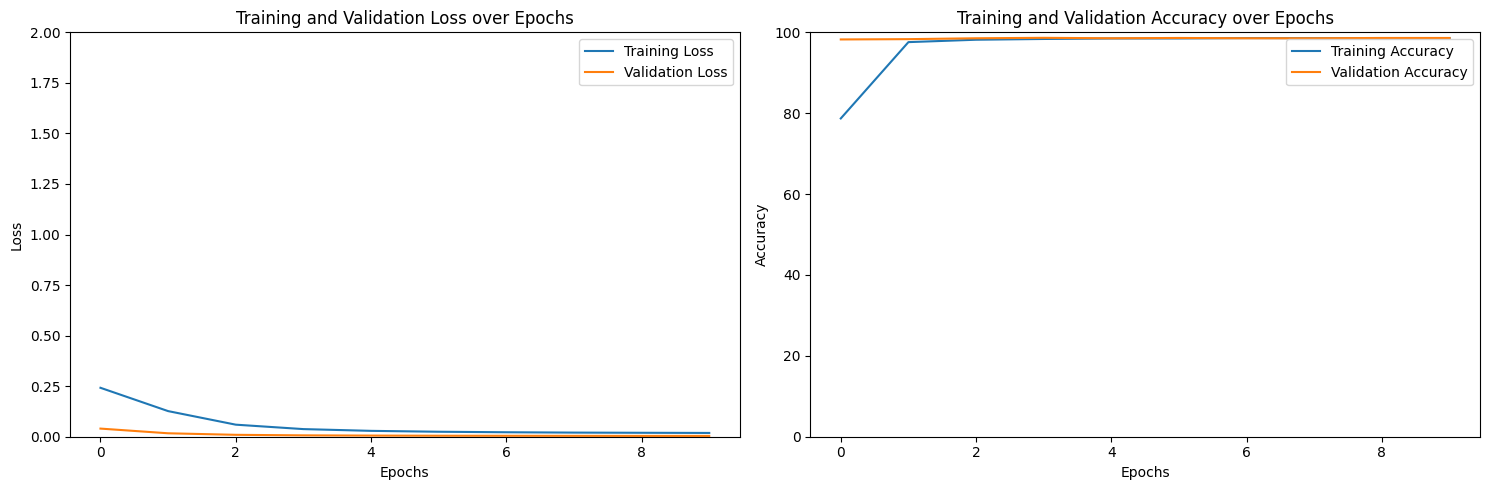

In [18]:
#lets plot losses first
fig, axes= plt.subplots(nrows=1,ncols=2, figsize=(15,5))

axes[0].plot(total_loss_train_plot, label='Training Loss')
axes[0].plot(total_loss_val_plot, label='Validation Loss')
axes[0].set_title('Training and Validation Loss over Epochs')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_ylim([0,2])
axes[0].legend()

axes[1].plot(total_acc_train_plot, label='Training Accuracy')
axes[1].plot(total_acc_val_plot, label='Validation Accuracy')
axes[1].set_title('Training and Validation Accuracy over Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 100])
axes[1].legend()
plt.tight_layout()
plt.show()
